In [156]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pmt_read_data import pmt_read_data
from scipy.optimize import curve_fit

In [157]:
time_bg, counts_bg = pmt_read_data('./frequency_scan/background.txt')
time_1Hz_0_1, counts_1Hz_0_1 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_1H_scan_amp_0_1..txt')
time_1Hz_0_01, counts_1Hz_0_01 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_1H_scan_amp_0_01..txt')
time_1Hz_0_2, counts_1Hz_0_2 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_1H_scan_amp_0_2.txt')
time_1Hz_0_3,counts_1Hz_0_3 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_1H_scan_amp_0_3..txt')
time_1Hz_0_4, counts_1Hz_0_4 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_1H_scan_amp_0_4..txt')
time_1Hz_0_05, counts_1Hz_0_05 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_1H_scan_amp_0_05..txt')
time_1Hz_0_07,counts_1Hz_0_07 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_1H_scan_amp_0_07..txt')
time_1Hz_0_09,counts_1Hz_0_09 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_1H_scan_amp_0_09..txt')
time_5Hz_0_02,counts_5Hz_0_02 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_5H_scan_amp_0_02..txt')
time_5Hz_0_03,counts_5Hz_0_03 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_5H_scan_amp_0_03..txt')
time_5Hz_0_09,counts_5Hz_0_09 = pmt_read_data('./frequency_scan/oven_3_65A_422_scan_freq_5H_scan_amp_0_09..txt')

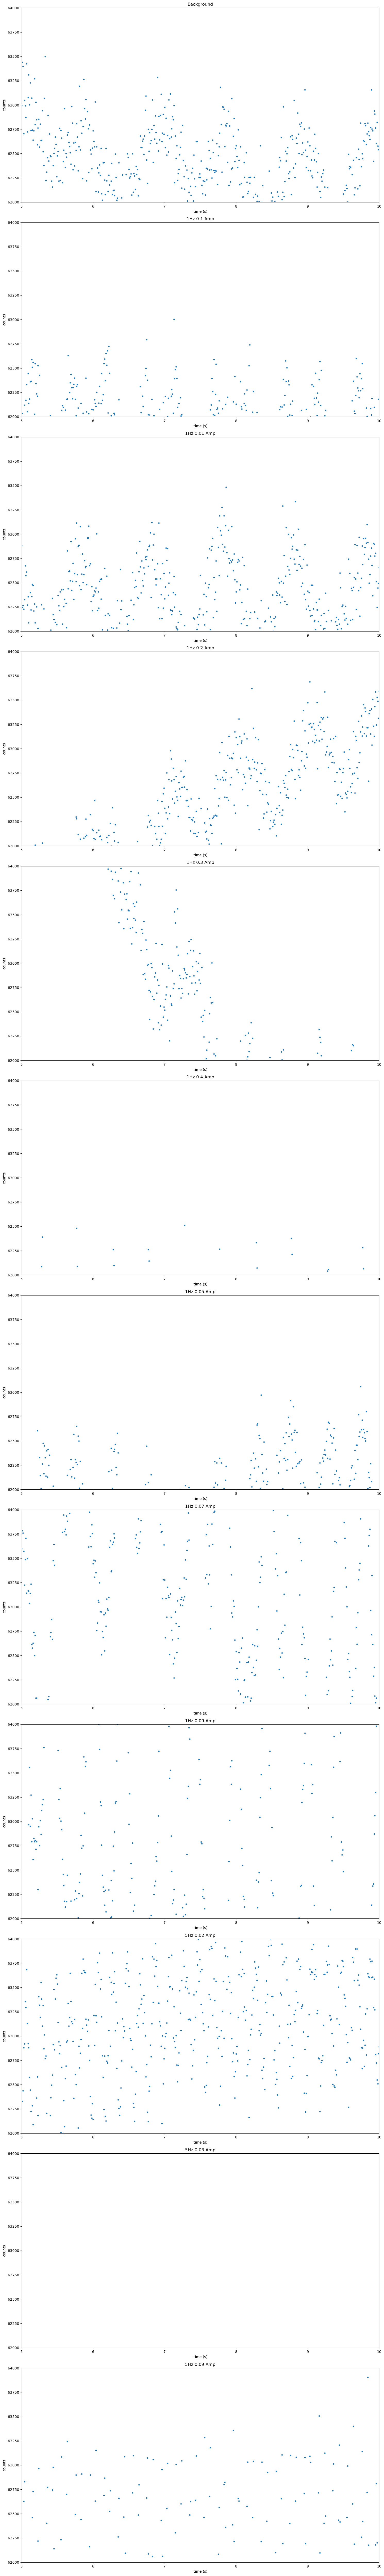

In [158]:
fig, axs = plt.subplots(12, 1, figsize=(15, 100))
axs = axs.flatten()

data = [
    (time_bg, counts_bg, 'Background'),
    (time_1Hz_0_1, counts_1Hz_0_1, '1Hz 0.1 Amp'),
    (time_1Hz_0_01, counts_1Hz_0_01, '1Hz 0.01 Amp'),
    (time_1Hz_0_2, counts_1Hz_0_2, '1Hz 0.2 Amp'),
    (time_1Hz_0_3, counts_1Hz_0_3, '1Hz 0.3 Amp'),
    (time_1Hz_0_4, counts_1Hz_0_4, '1Hz 0.4 Amp'),
    (time_1Hz_0_05, counts_1Hz_0_05, '1Hz 0.05 Amp'),
    (time_1Hz_0_07, counts_1Hz_0_07, '1Hz 0.07 Amp'),
    (time_1Hz_0_09, counts_1Hz_0_09, '1Hz 0.09 Amp'),
    (time_5Hz_0_02, counts_5Hz_0_02, '5Hz 0.02 Amp'),
    (time_5Hz_0_03, counts_5Hz_0_03, '5Hz 0.03 Amp'),
    (time_5Hz_0_09, counts_5Hz_0_09, '5Hz 0.09 Amp')
]

for ax, (time, counts, label) in zip(axs, data):
    ax.plot(time, counts, '.')
    ax.set_title(label)
    ax.set_ylim(62000, 64000)
    ax.set_xlim(5, 10)
    ax.set_xlabel('time (s)')
    ax.set_ylabel('counts')

plt.tight_layout()
plt.show()

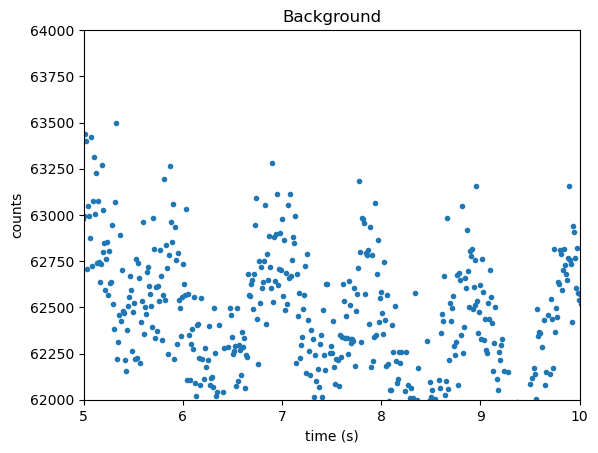

In [159]:
plt.plot(data[0][0], data[0][1], '.')
plt.ylim(62000, 64000)
plt.xlim(5, 10)
plt.title(data[0][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()

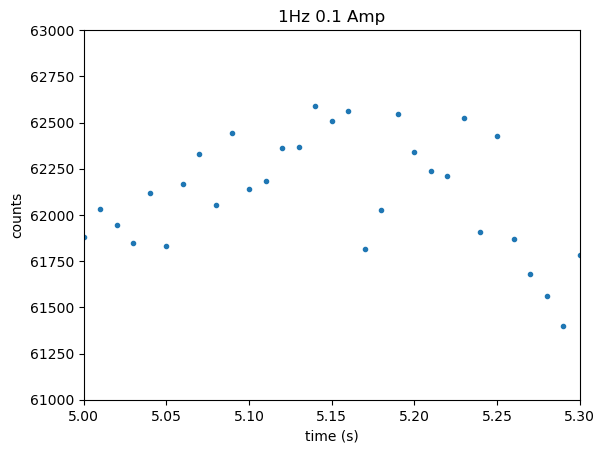

Max peak: 62589
Min peak: 61397
Count difference: 1192


In [160]:
plt.plot(data[1][0], data[1][1], '.', label='Background')
plt.ylim(61000, 63000)
plt.xlim(5, 5.3)
plt.xlabel('time (s)')
plt.title(data[1][2])
plt.ylabel('counts')
plt.show()
# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 5, 5.3
mask = (data[1][0] >= xlim_min) & (data[1][0] <= xlim_max)
counts_within_xlim = data[1][1][mask]

max_peak_1Hz_0_1 = counts_within_xlim.max()
min_peak_1Hz_0_1 = counts_within_xlim.min()
count_diff_1Hz_0_1 = max_peak_1Hz_0_1 - min_peak_1Hz_0_1

print(f"Max peak: {max_peak_1Hz_0_1}")
print(f"Min peak: {min_peak_1Hz_0_1}")
print(f"Count difference: {count_diff_1Hz_0_1}")

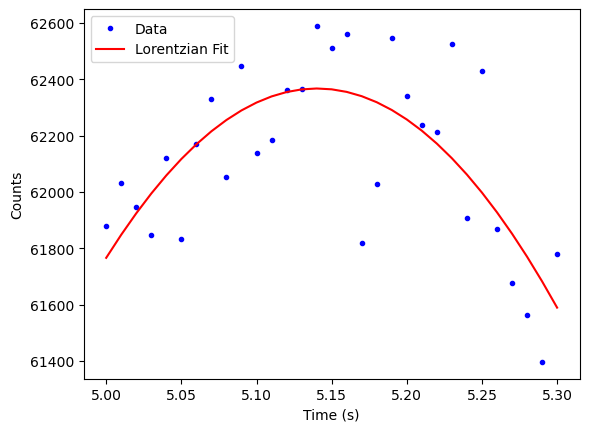

Fitted parameters: x0 = 5.140241715650305, gamma = 1.4220051177659856, A = 62367.031577019305


In [161]:


# Define the Lorentzian function
def lorentzian(x, x0, gamma, A):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)


# Define x_fit and y_fit based on the range of interest
x_fit = data[1][0][(data[1][0] >= xlim_min) & (data[1][0] <= xlim_max)]
y_fit = data[1][1][(data[1][0] >= xlim_min) & (data[1][0] <= xlim_max)]

x0_guess = 0.1
gamma_guess = 1
A_guess = max_peak_1Hz_0_1

# Fit the data to the Lorentzian function
popt, pcov = curve_fit(lorentzian, x_fit, y_fit, p0=(x0_guess, gamma_guess, A_guess))

# Extract the fitting parameters
x0_fit, gamma_fit, A_fit = popt

# Generate the fitted curve
y_fit_curve = lorentzian(x_fit, x0_fit, gamma_fit, A_fit)

# Plot the data and the fitted curve
plt.plot(x_fit, y_fit, 'b.', label='Data')
plt.plot(x_fit, y_fit_curve, 'r-', label='Lorentzian Fit')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.legend()
plt.show()

# Print the fitting parameters
print(f"Fitted parameters: x0 = {x0_fit}, gamma = {gamma_fit}, A = {A_fit}")

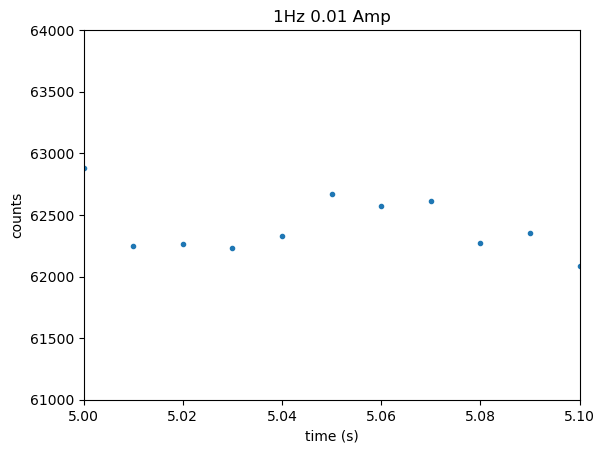

Max peak: 62880
Min peak: 62087
Count difference: 793


In [162]:
plt.plot(data[2][0], data[2][1], '.', label='Background')
plt.ylim(61000, 64000)
plt.xlim(5, 5.1)
plt.title(data[2][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()
# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 5, 5.1
mask = (data[2][0] >= xlim_min) & (data[2][0] <= xlim_max)
counts_within_xlim = data[2][1][mask]

max_peak_1Hz_0_01 = counts_within_xlim.max()
min_peak_1Hz_0_01 = counts_within_xlim.min()
count_diff_1Hz_0_01 = max_peak_1Hz_0_01 - min_peak_1Hz_0_01

print(f"Max peak: {max_peak_1Hz_0_01}")
print(f"Min peak: {min_peak_1Hz_0_01}")
print(f"Count difference: {count_diff_1Hz_0_01}")

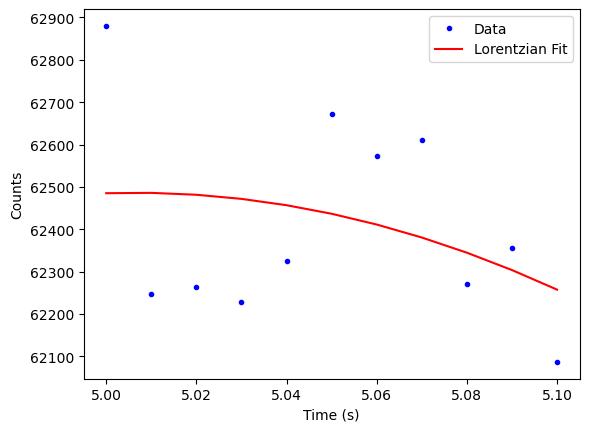

Fitted parameters: x0 = 5.006510081979531, gamma = 1.5424134315130205, A = 62486.304589385516


In [163]:

# Define x_fit and y_fit based on the range of interest
x_fit = data[2][0][(data[2][0] >= xlim_min) & (data[2][0] <= xlim_max)]
y_fit = data[2][1][(data[2][0] >= xlim_min) & (data[2][0] <= xlim_max)]

x0_guess = 0.1
gamma_guess = 1
A_guess = max_peak_1Hz_0_1

# Fit the data to the Lorentzian function
popt, pcov = curve_fit(lorentzian, x_fit, y_fit, p0=(x0_guess, gamma_guess, A_guess))

# Extract the fitting parameters
x0_fit, gamma_fit, A_fit = popt

# Generate the fitted curve
y_fit_curve = lorentzian(x_fit, x0_fit, gamma_fit, A_fit)

# Plot the data and the fitted curve
plt.plot(x_fit, y_fit, 'b.', label='Data')
plt.plot(x_fit, y_fit_curve, 'r-', label='Lorentzian Fit')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.legend()
plt.show()

# Print the fitting parameters
print(f"Fitted parameters: x0 = {x0_fit}, gamma = {gamma_fit}, A = {A_fit}")

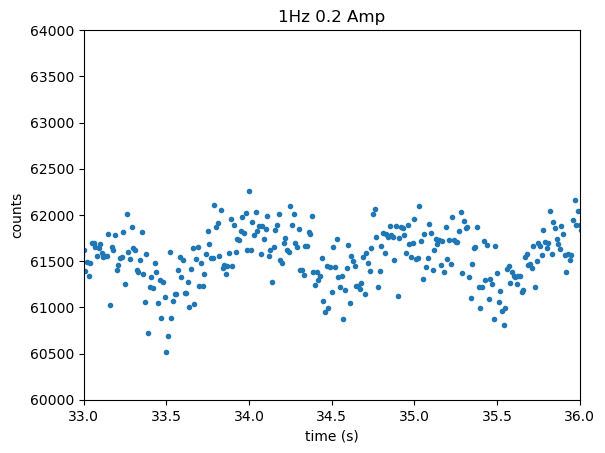

Max peak: 62254
Min peak: 60518
Count difference: 1736


In [164]:
plt.plot(data[3][0], data[3][1], '.', label='Background')
plt.ylim(60000, 64000)
plt.xlim(33, 36)
plt.title(data[3][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()
# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 33, 36
mask = (data[3][0] >= xlim_min) & (data[3][0] <= xlim_max)
counts_within_xlim = data[3][1][mask]

max_peak_1Hz_0_2 = counts_within_xlim.max()
min_peak_1Hz_0_2 = counts_within_xlim.min()
count_diff_1Hz_0_2 = max_peak_1Hz_0_2 - min_peak_1Hz_0_2

print(f"Max peak: {max_peak_1Hz_0_2}")
print(f"Min peak: {min_peak_1Hz_0_2}")
print(f"Count difference: {count_diff_1Hz_0_2}")

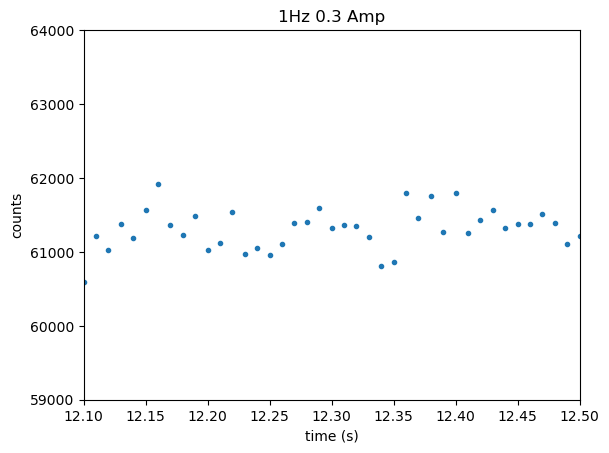

Max peak: 71594
Min peak: 70409
Count difference: 1185


In [165]:
plt.plot(data[4][0], data[4][1], '.', label='Background')
plt.ylim(59000, 64000)
plt.xlim(12.1, 12.5)
plt.title(data[4][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()

# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 12.1, 12.2
mask = (data[10][0] >= xlim_min) & (data[10][0] <= xlim_max)
counts_within_xlim = data[10][1][mask]

max_peak_1Hz_0_3 = counts_within_xlim.max()
min_peak_1Hz_0_3 = counts_within_xlim.min()
count_diff_1Hz_0_3 = max_peak_1Hz_0_3 - min_peak_1Hz_0_3

print(f"Max peak: {max_peak_1Hz_0_3}")
print(f"Min peak: {min_peak_1Hz_0_3}")
print(f"Count difference: {count_diff_1Hz_0_3}")
#this peak width is <0.05s

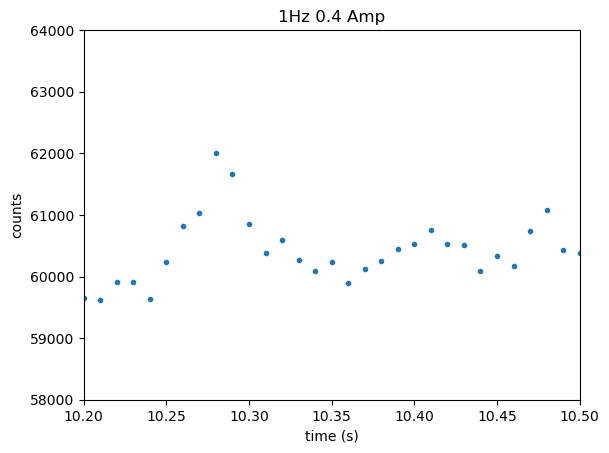

Max peak: 62009
Min peak: 58796
Count difference: 3213


In [176]:
plt.plot(data[5][0], data[5][1], '.')
plt.ylim(58000, 64000)
plt.xlim(10.2, 10.5)
plt.title(data[5][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()
# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 10, 12
mask = (data[5][0] >= xlim_min) & (data[5][0] <= xlim_max)
counts_within_xlim = data[5][1][mask]

max_peak_1Hz_0_3 = counts_within_xlim.max()
min_peak_1Hz_0_3 = counts_within_xlim.min()
count_diff_1Hz_0_3 = max_peak_1Hz_0_3 - min_peak_1Hz_0_3

print(f"Max peak: {max_peak_1Hz_0_3}")
print(f"Min peak: {min_peak_1Hz_0_3}")
print(f"Count difference: {count_diff_1Hz_0_3}")
#this width is slightly over 0.05s

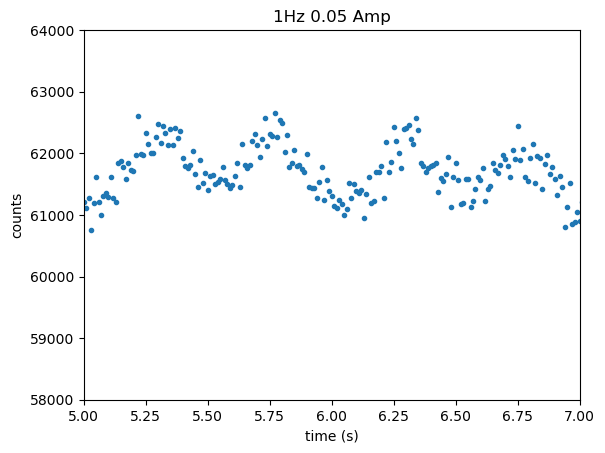

Max peak: 62652
Min peak: 60757
Count difference: 1895


In [167]:
plt.plot(data[6][0], data[6][1], '.')
plt.ylim(58000, 64000)
plt.xlim(5, 7)
plt.title(data[6][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()
# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 5, 7
mask = (data[6][0] >= xlim_min) & (data[6][0] <= xlim_max)
counts_within_xlim = data[6][1][mask]

max_peak_1Hz_0_05 = counts_within_xlim.max()
min_peak_1Hz_0_05 = counts_within_xlim.min()
count_diff_1Hz_0_05 = max_peak_1Hz_0_05 - min_peak_1Hz_0_05

print(f"Max peak: {max_peak_1Hz_0_05}")
print(f"Min peak: {min_peak_1Hz_0_05}")
print(f"Count difference: {count_diff_1Hz_0_05}")

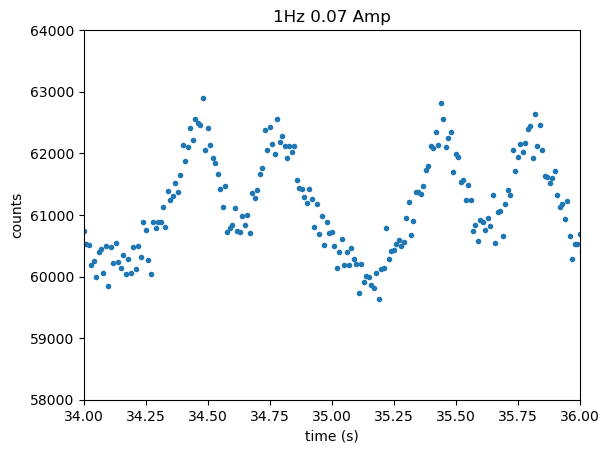

Max peak: 62892
Min peak: 59852
Count difference: 3040


In [177]:
plt.plot(data[7][0], data[7][1], '.')
plt.ylim(58000, 64000)
plt.xlim(34, 36)
plt.title(data[7][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()
# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 34, 35
mask = (data[7][0] >= xlim_min) & (data[7][0] <= xlim_max)
counts_within_xlim = data[7][1][mask]

max_peak_1Hz_0_07 = counts_within_xlim.max()
min_peak_1Hz_0_07 = counts_within_xlim.min()
count_diff_1Hz_0_07 = max_peak_1Hz_0_07 - min_peak_1Hz_0_07

print(f"Max peak: {max_peak_1Hz_0_07}")
print(f"Min peak: {min_peak_1Hz_0_07}")
print(f"Count difference: {count_diff_1Hz_0_07}")
#this width is about 34.6-34.4 = 0.2s

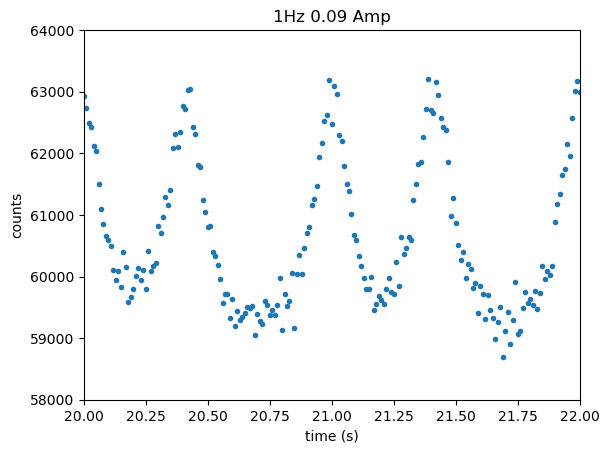

Max peak: 63214
Min peak: 58688
Count difference: 4526


In [ ]:
plt.plot(data[8][0], data[8][1], '.')
plt.ylim(58000, 64000)
plt.xlim(20, 22)
plt.title(data[8][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()
# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 20, 22
mask = (data[8][0] >= xlim_min) & (data[8][0] <= xlim_max)
counts_within_xlim = data[8][1][mask]

max_peak_1Hz_0_09 = counts_within_xlim.max()
min_peak_1Hz_0_09 = counts_within_xlim.min()
count_diff_1Hz_0_09 = max_peak_1Hz_0_09 - min_peak_1Hz_0_09

print(f"Max peak: {max_peak_1Hz_0_09}")
print(f"Min peak: {min_peak_1Hz_0_09}")
print(f"Count difference: {count_diff_1Hz_0_09}")
#this width is about 21.25-20.75=0.5s

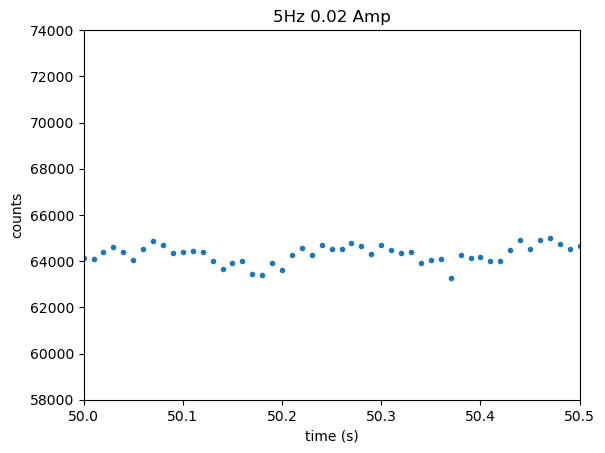

Max peak: 65013
Min peak: 63259
Count difference: 1754


In [170]:
plt.plot(data[9][0], data[9][1], '.')
plt.ylim(58000, 74000)
plt.xlim(50, 50.5)
plt.title(data[9][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()
# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 50, 50.5
mask = (data[9][0] >= xlim_min) & (data[9][0] <= xlim_max)
counts_within_xlim = data[9][1][mask]

max_peak_5Hz_0_02 = counts_within_xlim.max()
min_peak_5Hz_0_02 = counts_within_xlim.min()
count_diff_5Hz_0_02 = max_peak_5Hz_0_02 - min_peak_5Hz_0_02

print(f"Max peak: {max_peak_5Hz_0_02}")
print(f"Min peak: {min_peak_5Hz_0_02}")
print(f"Count difference: {count_diff_5Hz_0_02}")

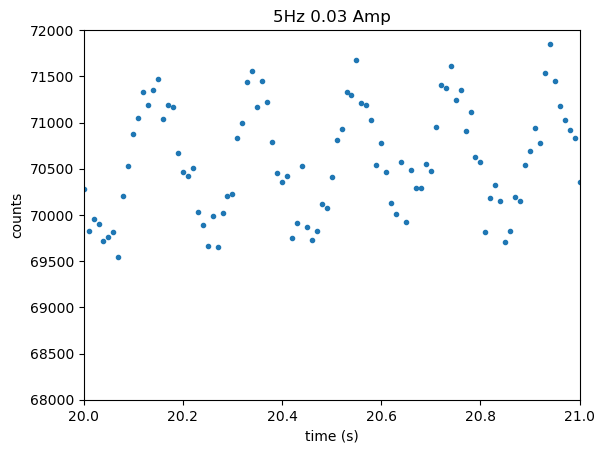

Max peak: 71849
Min peak: 69550
Count difference: 2299


In [171]:
plt.plot(data[10][0], data[10][1], '.')
plt.ylim(68000, 72000)
plt.xlim(20, 21)
plt.title(data[10][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()

# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 20, 21
mask = (data[10][0] >= xlim_min) & (data[10][0] <= xlim_max)
counts_within_xlim = data[10][1][mask]

max_peak_5Hz_0_03 = counts_within_xlim.max()
min_peak_5Hz_0_03 = counts_within_xlim.min()
count_diff_5Hz_0_03 = max_peak_5Hz_0_03 - min_peak_5Hz_0_03

print(f"Max peak: {max_peak_5Hz_0_03}")
print(f"Min peak: {min_peak_5Hz_0_03}")
print(f"Count difference: {count_diff_5Hz_0_03}")

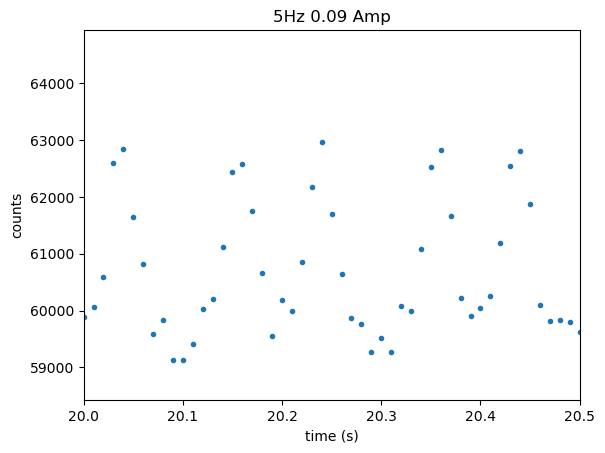

Max peak: 62959
Min peak: 59121
Count difference: 3838


In [172]:
plt.plot(data[11][0], data[11][1], '.')
#plt.ylim(68000, 72000)
plt.xlim(20, 20.5)
plt.title(data[11][2])
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.show()
# Find the max, min, and average of the peaks within the specified xlim
xlim_min, xlim_max = 20, 20.5
mask = (data[11][0] >= xlim_min) & (data[11][0] <= xlim_max)
counts_within_xlim = data[11][1][mask]

max_peak_5Hz_0_09 = counts_within_xlim.max()
min_peak_5Hz_0_09 = counts_within_xlim.min()
count_diff_5Hz_0_09 = max_peak_5Hz_0_09 - min_peak_5Hz_0_09

print(f"Max peak: {max_peak_5Hz_0_09}")
print(f"Min peak: {min_peak_5Hz_0_09}")
print(f"Count difference: {count_diff_5Hz_0_09}")

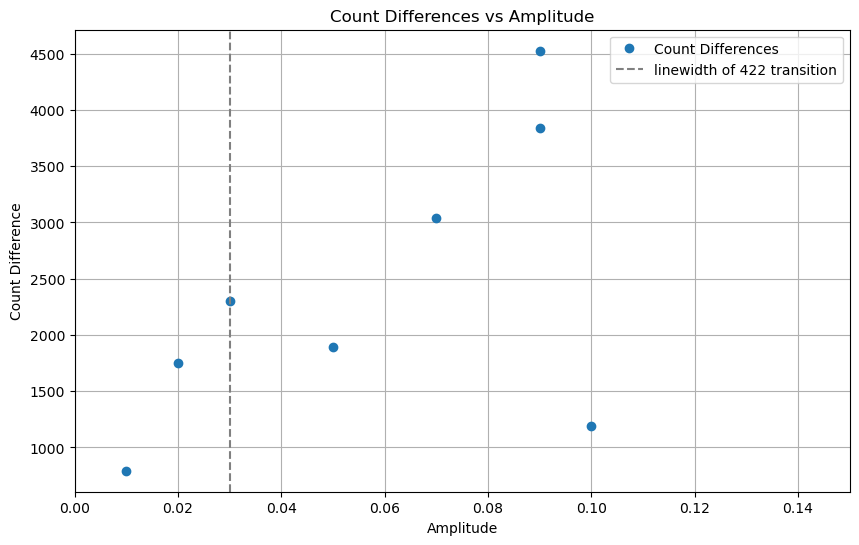

In [173]:
# Extract amplitudes and count differences
amplitudes = [
    0.01, 0.05, 0.07, 0.09, 0.1, 0.2, 0.3, 0.02, 0.03, 0.09
]
count_diffs = [
    count_diff_1Hz_0_01, count_diff_1Hz_0_05, count_diff_1Hz_0_07, count_diff_1Hz_0_09,
    count_diff_1Hz_0_1, count_diff_1Hz_0_2, count_diff_1Hz_0_3, count_diff_5Hz_0_02,
    count_diff_5Hz_0_03, count_diff_5Hz_0_09
]

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(amplitudes, count_diffs, 'o', label='Count Differences')
plt.xlabel('Amplitude')
plt.ylabel('Count Difference')
plt.title('Count Differences vs Amplitude')
plt.axvline(0.03,label = "linewidth of 422 transition",linestyle='--',color = "gray")
plt.xlim(0,0.15)
plt.grid(True)
plt.legend()
plt.show()